# Stoke Prediction — PCA, Linear Regression, XGBoost (Final)

**Model:** XGBoost with `RandomizedSearchCV` (100 iterations, 5-fold CV)  
**Data:** EPA EQI (2011–2015) merged with CDC PLACES (2020), ~71k census tracts  
**Targets:** 4 chronic disease prevalence measures (STROKE, KIDNEY, CHD, CANCER)  
**Features:** 37 environmental, demographic, and health behavior variables  
**Preprocessing:** Median imputation → MinMaxScaler → stratified 80/20 train/test split by State

---
## 1. Setup & Data Loading

In [1]:
# base imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# sklearn imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# pandas display options
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

# load data
cdc_epa_data = pd.read_csv(
    "EQI_2011_2015_PLACES_2020_merged.csv"
)
print(f"Loaded: {cdc_epa_data.shape[0]:,} rows, {cdc_epa_data.shape[1]} columns")

Loaded: 70,962 rows, 73 columns


In [9]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

features = [
    'X_pop_dens', 'facilities_area', 'pest', 'bs_25yo', 'time2work', 'crime_index',
    'education_area', 'food_ratio', 'nindex_open', 'nata_sum', 'ozone', 'pm25',
    'poverty', 'rent_income_pct', 'selfservice', 'unemployment',
    'PLACES_ACCESS2', 'PLACES_ARTHRITIS', 'PLACES_BINGE', 'PLACES_BPHIGH', 'PLACES_BPMED',
    'PLACES_CASTHMA', 'PLACES_CERVICAL', 'PLACES_CHD', 'PLACES_CHECKUP',
    'PLACES_CHOLSCREEN', 'PLACES_COLON_SCREEN', 'PLACES_COPD', 'PLACES_COREM',
    'PLACES_COREW', 'PLACES_CSMOKING', 'PLACES_DENTAL', 'PLACES_DIABETES',
    'PLACES_HIGHCHOL', 'PLACES_KIDNEY', 'PLACES_LPA', 'PLACES_MAMMOUSE',
    'PLACES_MHLTH', 'PLACES_OBESITY', 'PLACES_PHLTH', 'PLACES_SLEEP',
    'PLACES_TEETHLOST', 'PLACES_CANCER',
    'RUCA_pri_cat']

X_for_pca = cdc_epa_data[features]

X_numerical = X_for_pca.drop(['RUCA_pri_cat'], axis=1).copy()

imputer = SimpleImputer(strategy='median') # Impute missing values
X_numerical_imputed = imputer.fit_transform(X_numerical)

scaler = StandardScaler() # Scale numerical data
X_numerical_imputed_scaled = pd.DataFrame(scaler.fit_transform(X_numerical_imputed), columns=X_numerical.columns)

print("Shape of X_numerical_imputed_scaled:", X_numerical_imputed_scaled.shape)
print("First 5 rows of X_scaled:")
print(X_numerical_imputed_scaled.head())

print('\n', '\n')

# One-hot encode the 'RUCA_pri_cat' categorical variable/column
X_RUCA_onehot = pd.get_dummies(X_for_pca['RUCA_pri_cat'], prefix='RUCA', drop_first=True)

print("Shape of X_RUCA_onehot:", X_RUCA_onehot.shape)
print("First 5 rows of X_RUCA_onehot:")
print(X_RUCA_onehot.head())


Shape of X_numerical_imputed_scaled: (70962, 43)
First 5 rows of X_scaled:
   X_pop_dens  facilities_area    pest  bs_25yo  time2work  crime_index  \
0     -0.4048          -0.2100 -0.1350  -0.0499    -0.0921      -0.4257   
1     -0.3049          -0.1399 -0.1423  -0.7496    -0.3234       0.8291   
2     -0.3090          -0.2100 -0.1058  -0.4105    -0.8727       0.2435   
3     -0.2966          -0.2100 -0.0962  -0.2113    -0.0487      -0.2465   
4     -0.2400          -0.2100  0.0212   0.7790    -0.1210       0.5064   

   education_area  food_ratio  nindex_open  nata_sum   ozone   pm25  poverty  \
0         -0.3058      2.8580       1.3970    2.3894 -0.2006 0.7859  -0.6750   
1         -0.0913     -0.1790       0.9561    2.5139 -0.1962 0.8216   0.6039   
2         -0.2675      0.1247       0.6504    2.5639 -0.1932 0.8429  -0.4776   
3         -0.1775      1.0358       0.4573    2.6326 -0.1887 0.8790  -0.9926   
4         -0.2250      0.3731      -0.2567    2.6877 -0.1842 0.9121  -0.44

In [11]:
# Concatenate the numerical predictors with the one-hot encoded categorical columns
X_pca_ready = pd.concat([X_numerical_imputed_scaled, X_RUCA_onehot], axis=1)

# Instantiate PCA
pca = PCA()

# Fit PCA to the imputed scaled data and transform it
X_pca = pca.fit_transform(X_pca_ready)

print("Shape of PCA-transformed data:", X_pca.shape)
print("First 5 rows of PCA-transformed data:")
print(X_pca[:5])

print('\n', '\n')
# Get the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

print("Explained variance ratio of each principal component:")
print(explained_variance_ratio[:5]) # Print first 5 components for brevity
print(f"Total explained variance by first 5 components: {explained_variance_ratio[:5].sum():.2f}")
print("\n")
print("Explained variance ratio of each principal component:")
print(explained_variance_ratio[:10]) # Print first 10 components for brevity
print(f"Total explained variance by first 10 components: {explained_variance_ratio[:10].sum():.2f}")
print("\n")
print("Explained variance ratio of each principal component:")
print(explained_variance_ratio[:20]) # Print first 20 components for brevity
print(f"Total explained variance by first 20 components: {explained_variance_ratio[:20].sum():.2f}")

Shape of PCA-transformed data: (70962, 47)
First 5 rows of PCA-transformed data:
[[-8.45407446e-01  1.76271046e+00  4.53969987e-01  1.91143413e+00
   1.59717875e+00 -4.38002454e-01  2.03995555e+00 -1.15089160e+00
   5.35839861e-01  6.20232964e-01  1.83255115e+00  8.09449881e-01
  -1.59103606e+00 -2.53391012e-01  1.26963704e-01  3.40356283e-01
  -6.74106407e-01  3.41153618e-01 -8.80854313e-01  5.61806829e-01
  -4.51815764e-02 -4.24596949e-01 -4.04512416e-01  1.74362289e-01
   1.58325681e-01  6.37105599e-02 -2.38734616e-01 -3.90388876e-02
   2.15085373e-03  2.63241155e-01 -8.69049173e-02 -6.73607064e-03
  -2.31907549e-01  7.52241475e-02 -3.01188705e-01  2.17101708e-02
  -1.03004700e-01 -1.04769480e-02 -3.17842468e-02  2.84817071e-01
   1.14320815e-01  5.22810231e-02  1.86631379e-01 -2.80587676e-02
  -7.09143530e-02 -1.42314943e-01  9.71125609e-02]
 [ 2.92850592e+00  5.32462604e-01  1.95822553e+00  2.37239214e+00
   1.68410199e+00 -2.13822666e-01  2.28521865e-01 -8.45074801e-01
   2.39396

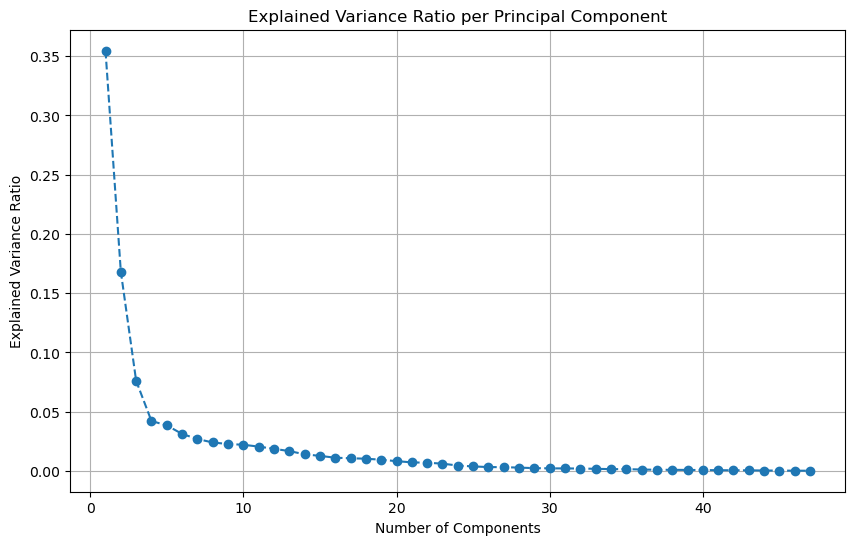

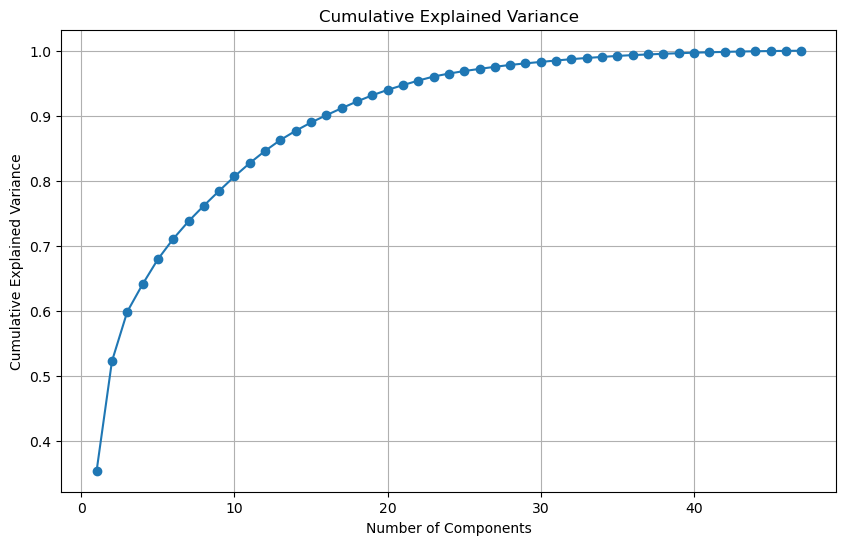

In [14]:
import matplotlib.pyplot as plt

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

# Plot the cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Select the first 20 principal components
X_pca_20 = X_pca[:, :20]

y = cdc_epa_data['PLACES_STROKE']

# Split the PCA-transformed data into training and test sets
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca_20, y, test_size=0.2, random_state=42)

print(f"Shape of X_train_pca: {X_train_pca.shape}")
print(f"Shape of X_test_pca: {X_test_pca.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Define the parameter grid for Ridge regression
param_grid_ridge = {
    'alpha': np.logspace(-4, 2, 100) # Alpha values from 0.0001 to 100
}

# Instantiate Ridge Regression model
ridge_model = Ridge(random_state=42)

# Instantiate GridSearchCV
grid_search_ridge = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid_ridge,
    scoring='r2', # Use R-squared as the scoring metric
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

print("\nStarting GridSearchCV for Ridge Regression...")

# Fit GridSearchCV to the training data (PCA components)
grid_search_ridge.fit(X_train_pca, y_train)

print("GridSearchCV for Ridge Regression complete.")

# Print the best parameters found
print("\nBest parameters found for Ridge Regression:", grid_search_ridge.best_params_)

# Print the best R-squared score found
print(f"Best R-squared from GridSearchCV (Ridge): {grid_search_ridge.best_score_:.4f}")

# Get the best Ridge model
best_ridge_model = grid_search_ridge.best_estimator_

# Make predictions on the test set using the best model
y_pred_ridge = best_ridge_model.predict(X_test_pca)

# Evaluate the model on the test set
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"\nTest Set R-squared (Ridge Regression with PCA): {r2_ridge:.4f}")
print(f"Test Set RMSE (Ridge Regression with PCA): {rmse_ridge:.4f}")



Shape of X_train_pca: (56769, 20)
Shape of X_test_pca: (14193, 20)
Shape of y_train: (56769,)
Shape of y_test: (14193,)

Starting GridSearchCV for Ridge Regression...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
GridSearchCV for Ridge Regression complete.

Best parameters found for Ridge Regression: {'alpha': np.float64(43.287612810830616)}
Best R-squared from GridSearchCV (Ridge): 0.9357

Test Set R-squared (Ridge Regression with PCA): 0.9354
Test Set RMSE (Ridge Regression with PCA): 0.3184


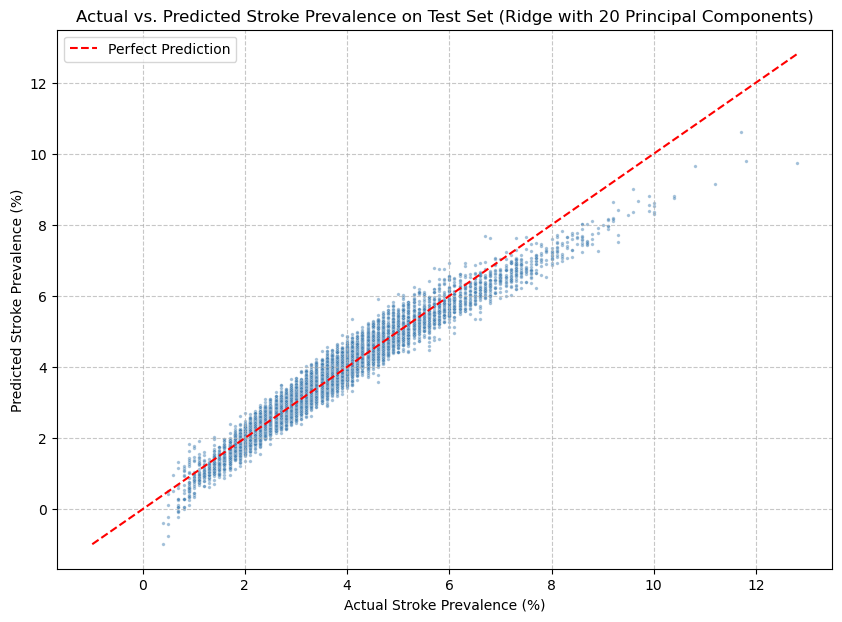

In [21]:
# Visualize predictions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.5, s=6, color='steelblue')
min_val = min(y_test.min(), y_pred_ridge.min())
max_val = max(y_test.max(), y_pred_ridge.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Stroke Prevalence (%)')
plt.ylabel('Predicted Stroke Prevalence (%)')
plt.title('Actual vs. Predicted Stroke Prevalence on Test Set (Ridge with 20 Principal Components)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [22]:
# Select the first 25 principal components
X_pca_25 = X_pca[:, :25]

y = cdc_epa_data['PLACES_STROKE']

# Split the PCA-transformed data into training and test sets
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca_25, y, test_size=0.2, random_state=42)

print(f"Shape of X_train_pca: {X_train_pca.shape}")
print(f"Shape of X_test_pca: {X_test_pca.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Define the parameter grid for Ridge regression
param_grid_ridge = {
    'alpha': np.logspace(-4, 2, 100) # Alpha values from 0.0001 to 100
}

# Instantiate Ridge Regression model
ridge_model = Ridge(random_state=42)

# Instantiate GridSearchCV
grid_search_ridge = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid_ridge,
    scoring='r2', # Use R-squared as the scoring metric
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

print("\nStarting GridSearchCV for Ridge Regression...")

# Fit GridSearchCV to the training data (PCA components)
grid_search_ridge.fit(X_train_pca, y_train)

print("GridSearchCV for Ridge Regression complete.")

# Print the best parameters found
print("\nBest parameters found for Ridge Regression:", grid_search_ridge.best_params_)

# Print the best R-squared score found
print(f"Best R-squared from GridSearchCV (Ridge): {grid_search_ridge.best_score_:.4f}")

# Get the best Ridge model
best_ridge_model = grid_search_ridge.best_estimator_

# Make predictions on the test set using the best model
y_pred_ridge = best_ridge_model.predict(X_test_pca)

# Evaluate the model on the test set
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"\nTest Set R-squared (Ridge Regression with PCA): {r2_ridge:.4f}")
print(f"Test Set RMSE (Ridge Regression with PCA): {rmse_ridge:.4f}")



Shape of X_train_pca: (56769, 25)
Shape of X_test_pca: (14193, 25)
Shape of y_train: (56769,)
Shape of y_test: (14193,)

Starting GridSearchCV for Ridge Regression...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
GridSearchCV for Ridge Regression complete.

Best parameters found for Ridge Regression: {'alpha': np.float64(18.73817422860383)}
Best R-squared from GridSearchCV (Ridge): 0.9494

Test Set R-squared (Ridge Regression with PCA): 0.9499
Test Set RMSE (Ridge Regression with PCA): 0.2804


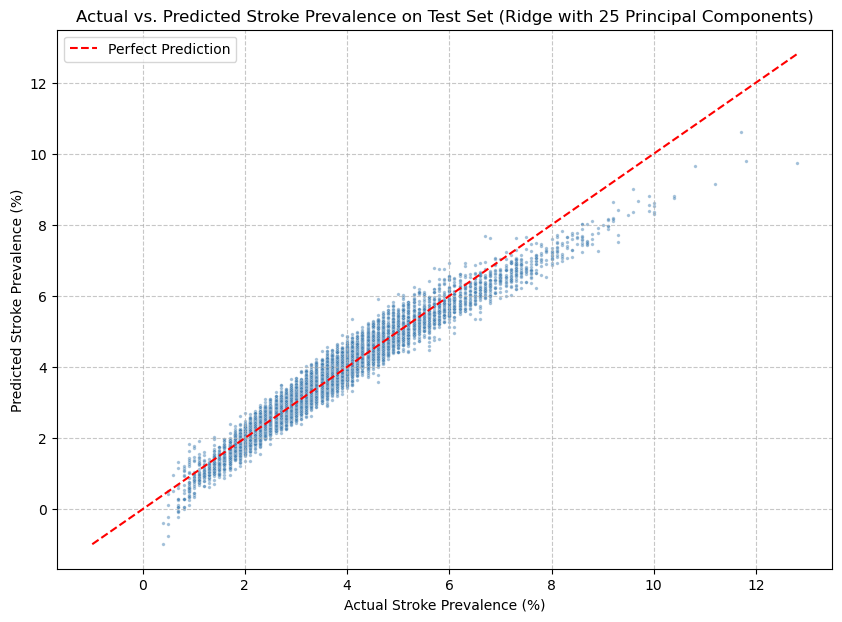

In [23]:
# Visualize predictions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.5, s=6, color='steelblue')
min_val = min(y_test.min(), y_pred_ridge.min())
max_val = max(y_test.max(), y_pred_ridge.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Stroke Prevalence (%)')
plt.ylabel('Predicted Stroke Prevalence (%)')
plt.title('Actual vs. Predicted Stroke Prevalence on Test Set (Ridge with 25 Principal Components)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

---
## 2. Variable Selection & Train/Test Split

In [3]:
variables_of_interest = [
    'X_pop_dens', 'facilities_area', 'pest', 'bs_25yo', 'time2work', 'crime_index',
    'education_area', 'food_ratio', 'nindex_open', 'nata_sum', 'ozone', 'pm25',
    'poverty', 'rent_income_pct', 'selfservice', 'unemployment',
    'PLACES_ACCESS2', 'PLACES_ARTHRITIS', 'PLACES_BINGE', 'PLACES_BPHIGH', 'PLACES_BPMED',
    'PLACES_CASTHMA', 'PLACES_CERVICAL', 'PLACES_CHD', 'PLACES_CHECKUP',
    'PLACES_CHOLSCREEN', 'PLACES_COLON_SCREEN', 'PLACES_COPD', 'PLACES_COREM',
    'PLACES_COREW', 'PLACES_CSMOKING', 'PLACES_DENTAL', 'PLACES_DIABETES',
    'PLACES_HIGHCHOL', 'PLACES_KIDNEY', 'PLACES_LPA', 'PLACES_MAMMOUSE',
    'PLACES_MHLTH', 'PLACES_OBESITY', 'PLACES_PHLTH', 'PLACES_SLEEP', 'PLACES_STROKE',
    'PLACES_TEETHLOST', 'PLACES_CANCER',
    'RUCA_pri_cat',
    'tract_fips', 'State', 'County', 'StateAbbr', 'CountyName',
]

cdc_epa_selected = cdc_epa_data[variables_of_interest]

# stratified 80/20 split by state
cdc_epa_train, cdc_epa_test = train_test_split(
    cdc_epa_selected, test_size=0.2, random_state=5003,
    stratify=cdc_epa_selected['State']
)

print(f"Train: {len(cdc_epa_train):,}  Test: {len(cdc_epa_test):,}")
print(f"\nMissing values in train:\n{cdc_epa_train.isnull().sum()[cdc_epa_train.isnull().sum() > 0]}")

Train: 56,769  Test: 14,193

Missing values in train:
PLACES_COLON_SCREEN     2
PLACES_COREM           43
PLACES_COREW           38
PLACES_MAMMOUSE         6
PLACES_TEETHLOST       24
dtype: int64


---
## 3. Define Targets, Features, and Hyperparameter Grid

In [4]:
targets = [
    'PLACES_STROKE', 'PLACES_KIDNEY',
    'PLACES_CHD', 'PLACES_CANCER',
]

id_cols = ['tract_fips', 'State', 'County', 'StateAbbr', 'CountyName']

feature_cols = [c for c in cdc_epa_train.columns if c not in id_cols + targets]
num_cols = [c for c in feature_cols if cdc_epa_train[c].dtype in ['float64', 'int64']]

print(f"Features: {len(feature_cols)}  |  Numeric: {len(num_cols)}  |  Targets: {len(targets)}")

xgb_params_v2 = {
    'n_estimators': [400, 500, 600, 800],
    'max_depth': [6, 7, 8, 10],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.75, 0.8, 0.85],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 2, 5],
    'gamma': [0, 0.1, 0.3],
}

Features: 41  |  Numeric: 41  |  Targets: 4


---
## 4. XGBoost V2 — RandomizedSearchCV (Primary Results)

In [5]:
results_v2 = []

for target in targets:
    X_train = cdc_epa_train[feature_cols].copy()
    y_train = cdc_epa_train[target]
    X_test = cdc_epa_test[feature_cols].copy()
    y_test = cdc_epa_test[target]

    imputer = SimpleImputer(strategy='median')
    X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
    X_test[num_cols] = imputer.transform(X_test[num_cols])

    scaler = MinMaxScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    xgb_cv = RandomizedSearchCV(
        XGBRegressor(random_state=5003),
        xgb_params_v2, n_iter=100, cv=5, scoring='r2',
        random_state=5003, n_jobs=-1
    )
    xgb_cv.fit(X_train, y_train)

    y_pred = xgb_cv.predict(X_test)
    rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    r2 = round(r2_score(y_test, y_pred), 4)
    best = xgb_cv.best_params_

    print(f"{target.replace('PLACES_', ''):12s}  R²: {r2}  RMSE: {rmse}")

    results_v2.append({
        'Target': target.replace('PLACES_', ''),
        'R²': r2, 'RMSE': rmse,
        'best_params': best,
        'model': xgb_cv.best_estimator_,
        'imputer': imputer,
        'scaler': scaler,
        'y_test': y_test.values,
        'y_pred': y_pred,
    })

results_v2_df = pd.DataFrame(results_v2).sort_values('R²', ascending=False)
results_v2_df[['Target', 'R²', 'RMSE']]

STROKE        R²: 0.9921  RMSE: 0.1115
KIDNEY        R²: 0.9892  RMSE: 0.0862
CHD           R²: 0.9908  RMSE: 0.2131
CANCER        R²: 0.9885  RMSE: 0.1988


,Target,R²,RMSE
0,STROKE,0.9921,0.1115
2,CHD,0.9908,0.2131
1,KIDNEY,0.9892,0.0862
3,CANCER,0.9885,0.1988


---
## 5. Best Hyperparameters Table

In [6]:
params_df = pd.DataFrame([
    {'Target': r['Target'], 'R²': r['R²'], 'RMSE': r['RMSE'], **r['best_params']}
    for r in results_v2
]).sort_values('R²', ascending=False)
params_df

,Target,R²,RMSE,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree
0,STROKE,0.9921,0.1115,0.7500,0.5000,0.1000,800,5,8,0.0700,0,0.8000
2,CHD,0.9908,0.2131,0.8500,2.0000,1.0000,800,5,7,0.0700,0,0.6000
1,KIDNEY,0.9892,0.0862,0.7500,0.5000,0.1000,800,5,8,0.0700,0,0.8000
3,CANCER,0.9885,0.1988,0.7500,0.5000,0.1000,800,5,8,0.0700,0,0.8000


In [26]:
# Train a final model for 'STROKE' with the best hyperparameters

X_train = cdc_epa_train[feature_cols].copy()
y_train = cdc_epa_train['PLACES_STROKE']
X_test = cdc_epa_test[feature_cols].copy()
y_test = cdc_epa_test['PLACES_STROKE']

# 1. Retrieve the optimal hyperparameters from grid_search.best_params_
best_stroke_params = {
    'n_estimators': 800,
    'max_depth': 8,
    'learning_rate': 0.07,
    'subsample': 0.75,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.5,
    'gamma': 0,
}
print("Optimal Hyperparameters for Stroke Modeling found by RandomizedSearchCV: \n", best_stroke_params)

# 2. Instantiate a new XGBRegressor model with optimal hyperparameters
final_stroke_xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best_stroke_params 
    )

print("\nInstantiated final XGBoost model with optimal hyperparameters.")

# 3. Train this final model using the entire X_train_val and y_train_val datasets
print("Training final tuned XGBoost model on the entire training/validation set...")
final_stroke_xgb_model.fit(X_train, y_train)
print("Final tuned model training complete.")

Optimal Hyperparameters for Stroke Modeling found by RandomizedSearchCV: 
 {'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.07, 'subsample': 0.75, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 0.5, 'gamma': 0}

Instantiated final XGBoost model with optimal hyperparameters.
Training final tuned XGBoost model on the entire training/validation set...
Final tuned model training complete.


In [28]:
# Compare model performance between the training and test sets
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the training data
y_train_pred = final_stroke_xgb_model.predict(X_train)

# Calculate R-squared on the training set
r2_train = r2_score(y_train, y_train_pred)

# Calculate RMSE on the training set
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("--- Performance of the Final XGBoost Stroke Prediction Model on Training Set ---")
print(f"R-squared on the training set: {r2_train:.4f}")
print(f"RMSE on the training set: {rmse_train: .4f}")

# Make predictions on the test set.

y_test_pred = final_stroke_xgb_model.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("--- Performance of the Final XGBoost Stroke Prediction Model on Test Set ---")
print(f"R-squared on the test set: {r2_test:.4f}")
print(f"RMSE on the test set: {rmse_test:.4f}")

# y_pred = xgb_cv.predict(X_test)
#     rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
#     r2 = round(r2_score(y_test, y_pred), 4)
#     best = xgb_cv.best_params_

#     print(f"{target.replace('PLACES_', ''):12s}  R²: {r2}  RMSE: {rmse}")

--- Performance of the Final XGBoost Stroke Prediction Model on Training Set ---
R-squared on the training set: 0.9994
RMSE on the training set:  0.0308
--- Performance of the Final XGBoost Stroke Prediction Model on Test Set ---
R-squared on the test set: 0.9919
RMSE on the test set: 0.1126


Top 20 Feature Importances from Tuned Model:
             Feature  Importance
31   PLACES_DIABETES      0.7349
26       PLACES_COPD      0.1176
19     PLACES_BPHIGH      0.0554
17  PLACES_ARTHRITIS      0.0204
37      PLACES_PHLTH      0.0148
21    PLACES_CASTHMA      0.0067
20      PLACES_BPMED      0.0057
38      PLACES_SLEEP      0.0045
36    PLACES_OBESITY      0.0042
22   PLACES_CERVICAL      0.0042
39  PLACES_TEETHLOST      0.0032
11              pm25      0.0022
40      RUCA_pri_cat      0.0021
16    PLACES_ACCESS2      0.0020
23    PLACES_CHECKUP      0.0017
28      PLACES_COREW      0.0015
27      PLACES_COREM      0.0014
34   PLACES_MAMMOUSE      0.0014
14       selfservice      0.0013
35      PLACES_MHLTH      0.0011


/tmp/ipykernel_454483/2206823363.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_tuned.head(20), palette='viridis')


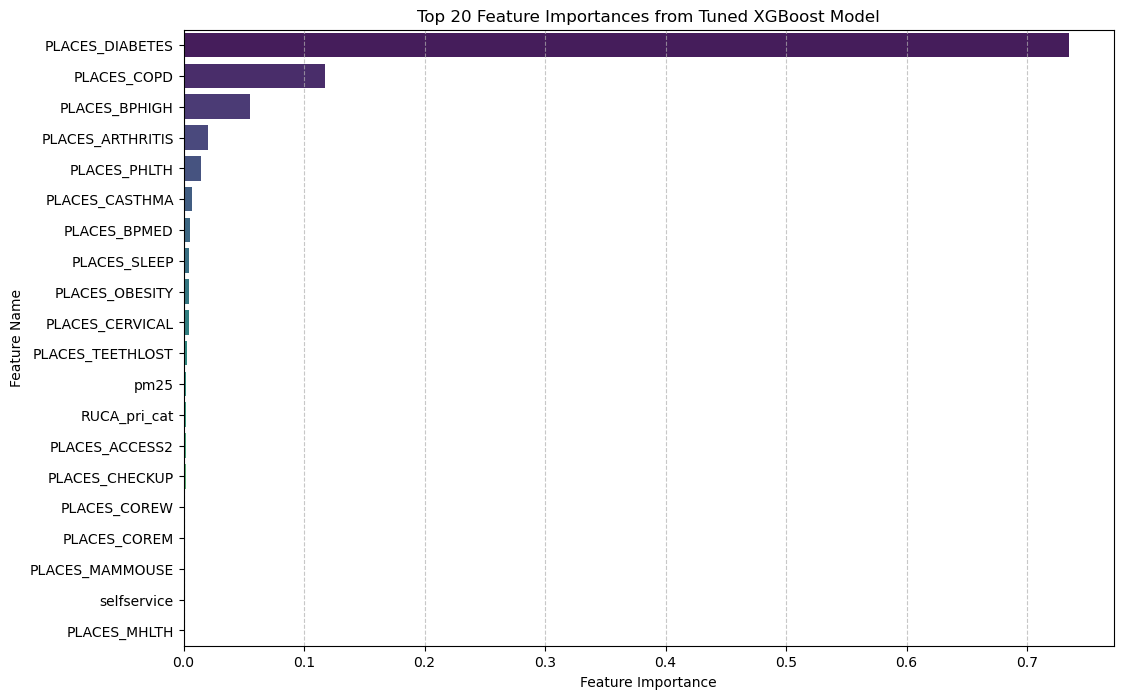

In [29]:
# Feature Importance Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the final TUNED model
feature_importances_tuned = final_stroke_xgb_model.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df_tuned = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances_tuned})

# Sort the DataFrame by importance in descending order
importance_df_tuned = importance_df_tuned.sort_values(by='Importance', ascending=False)

# Display the top 20 features
print("Top 20 Feature Importances from Tuned Model:")
print(importance_df_tuned.head(20))

# Visualize the top N features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_tuned.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from Tuned XGBoost Model')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

---
## 6. Actual vs Predicted Scatter Plots (National)

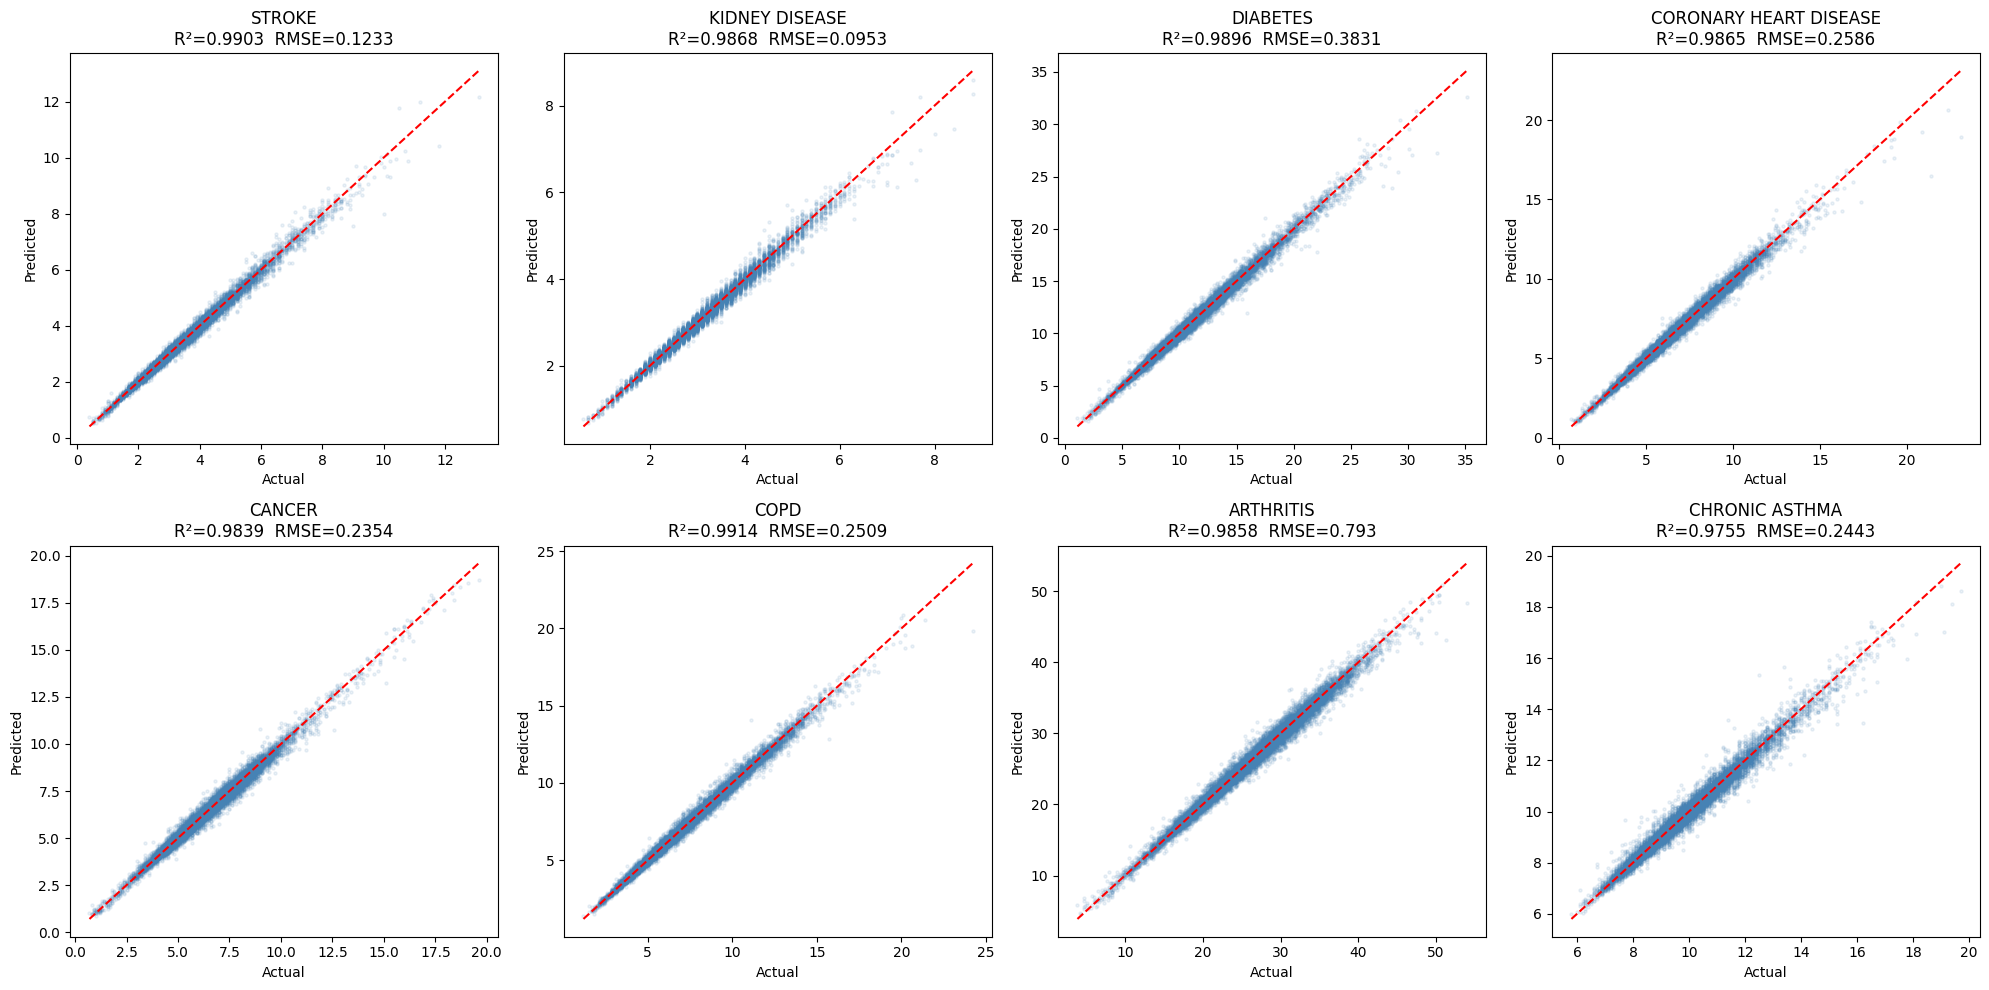

In [8]:
name_map = {
    'STROKE': 'STROKE', 'KIDNEY': 'KIDNEY DISEASE',
    'CANCER': 'CANCER', 'DIABETES': 'DIABETES',
    'COPD': 'COPD', 'ARTHRITIS': 'ARTHRITIS',
    'CHD': 'CORONARY HEART DISEASE', 'CASTHMA': 'CHRONIC ASTHMA',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, row in enumerate(results_v2):
    ax = axes[i]
    ax.scatter(row['y_test'], row['y_pred'], alpha=0.1, s=5, color='steelblue')
    lo = min(row['y_test'].min(), row['y_pred'].min())
    hi = max(row['y_test'].max(), row['y_pred'].max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_title(f"{name_map[row['Target']]}\nR²={row['R²']}  RMSE={row['RMSE']}")
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('xgb_v2_actual_vs_predicted_national.png', dpi=150)
plt.show()

---
## 7. State-Level Evaluation

In [9]:
def evaluate_state(state_fips, state_name, results, test_df):
    """Evaluate model performance for a single state."""
    idx = np.where(test_df['State'] == state_fips)[0]
    print(f"\n{'='*50}")
    print(f"{state_name} (n={len(idx)} tracts)")
    print(f"{'='*50}")
    for row in results:
        y_test_st = row['y_test'][idx]
        y_pred_st = row['y_pred'][idx]
        rmse = round(np.sqrt(mean_squared_error(y_test_st, y_pred_st)), 4)
        r2 = round(r2_score(y_test_st, y_pred_st), 4)
        print(f"{row['Target']:12s}  R²: {r2}  RMSE: {rmse}")

# Virginia
evaluate_state(51, 'Virginia', results_v2, cdc_epa_test)

# California
evaluate_state(6, 'California', results_v2, cdc_epa_test)

# Wyoming
evaluate_state(56, 'Wyoming', results_v2, cdc_epa_test)

# Maine
evaluate_state(23, 'Maine', results_v2, cdc_epa_test)

# Vermont
evaluate_state(50, 'Vermont', results_v2, cdc_epa_test)

# Washington, D.C.
evaluate_state(11, 'Washington, D.C.', results_v2, cdc_epa_test)

# Georgia
evaluate_state(13, 'Georgia', results_v2, cdc_epa_test)

# Florida
evaluate_state(12, 'Florida', results_v2, cdc_epa_test)


Virginia (n=369 tracts)
STROKE        R²: 0.9919  RMSE: 0.1116
KIDNEY        R²: 0.9894  RMSE: 0.0834
DIABETES      R²: 0.9896  RMSE: 0.3495
CHD           R²: 0.9874  RMSE: 0.2469
CANCER        R²: 0.9808  RMSE: 0.2527
COPD          R²: 0.9942  RMSE: 0.199
ARTHRITIS     R²: 0.9863  RMSE: 0.7642
CASTHMA       R²: 0.9798  RMSE: 0.2072

California (n=1588 tracts)
STROKE        R²: 0.9855  RMSE: 0.1065
KIDNEY        R²: 0.9863  RMSE: 0.0802
DIABETES      R²: 0.9864  RMSE: 0.3403
CHD           R²: 0.9862  RMSE: 0.1904
CANCER        R²: 0.9887  RMSE: 0.2009
COPD          R²: 0.9878  RMSE: 0.1853
ARTHRITIS     R²: 0.9832  RMSE: 0.6439
CASTHMA       R²: 0.9733  RMSE: 0.1964

Wyoming (n=26 tracts)
STROKE        R²: 0.9807  RMSE: 0.1141
KIDNEY        R²: 0.9722  RMSE: 0.1022
DIABETES      R²: 0.9689  RMSE: 0.4357
CHD           R²: 0.9834  RMSE: 0.228
CANCER        R²: 0.9811  RMSE: 0.2574
COPD          R²: 0.977  RMSE: 0.2436
ARTHRITIS     R²: 0.9745  RMSE: 0.9425
CASTHMA       R²: 0.8421  RMSE

---
## 8. Virginia Scatter Plots

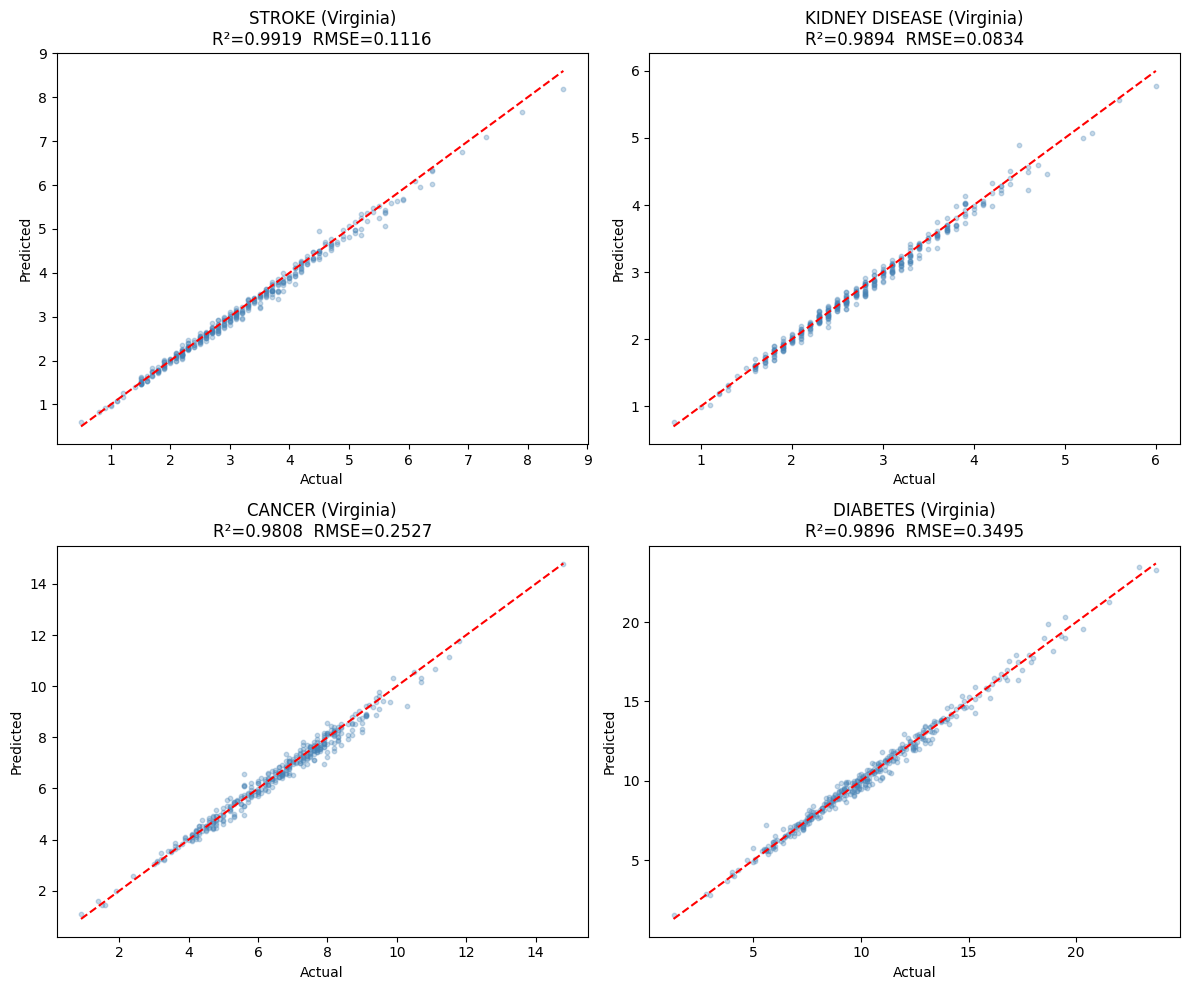

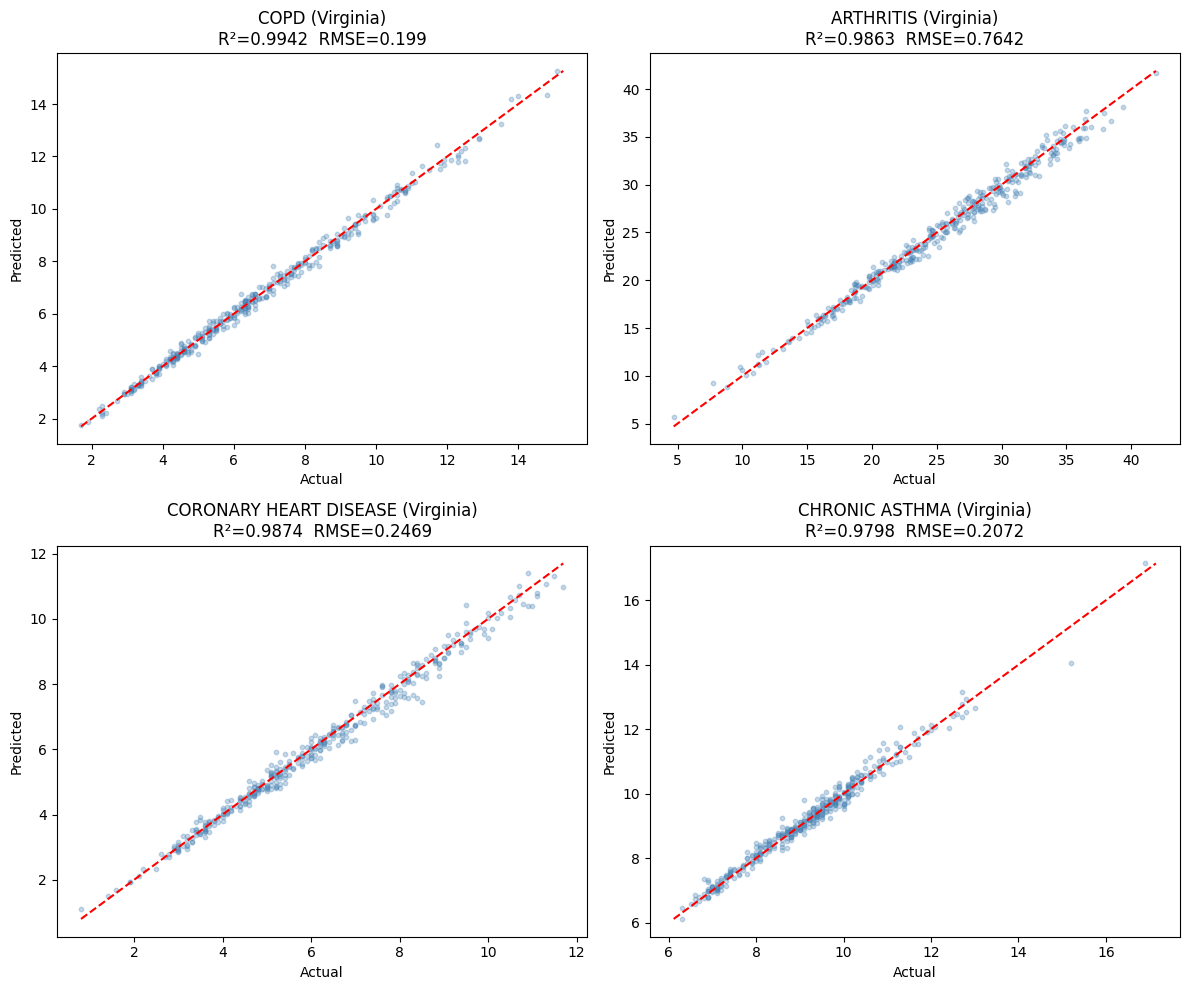

In [10]:
va_idx = np.where(cdc_epa_test['State'] == 51)[0]
v2_lookup = {row['Target']: row for row in results_v2}

group = ['STROKE', 'KIDNEY', 'CANCER', 'CHD']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, target in enumerate(group):
    row = v2_lookup[target]
    y_test_va = row['y_test'][va_idx]
    y_pred_va = row['y_pred'][va_idx]

    rmse = round(np.sqrt(mean_squared_error(y_test_va, y_pred_va)), 4)
    r2 = round(r2_score(y_test_va, y_pred_va), 4)

    ax = axes[i]
    ax.scatter(y_test_va, y_pred_va, alpha=0.3, s=10, color='steelblue')
    lo = min(y_test_va.min(), y_pred_va.min())
    hi = max(y_test_va.max(), y_pred_va.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_title(f"{name_map[target]} (Virginia)\nR²={r2}  RMSE={rmse}")
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('xgb_v2_VA_scatter.png', dpi=150)
plt.show()

---
## 9. Virginia County-Level Predictions & Ranking
Uses saved models to predict ALL Virginia tracts, then aggregates to county.

In [11]:
# get all Virginia tracts
va_all = cdc_epa_selected[cdc_epa_selected['State'] == 51].copy()
X_va = va_all[feature_cols].copy()

# predict each target using saved models with matching preprocessing
for row in results_v2:
    X_va_proc = va_all[feature_cols].copy()
    X_va_proc[num_cols] = row['imputer'].transform(X_va_proc[num_cols])
    X_va_proc[num_cols] = row['scaler'].transform(X_va_proc[num_cols])
    va_all[f"pred_{row['Target']}"] = row['model'].predict(X_va_proc)

# aggregate to county — mean predicted prevalence
agg_dict = {'tract_fips': 'count'}
for row in results_v2:
    t = row['Target']
    agg_dict[f'PLACES_{t}'] = 'mean'
    agg_dict[f'pred_{t}'] = 'mean'

va_county = va_all.groupby('CountyName').agg(agg_dict).round(2)
va_county.rename(columns={'tract_fips': 'n_tracts'}, inplace=True)

# show top counties by predicted cancer prevalence
va_county.sort_values('pred_CANCER', ascending=False).head(20)

,n_tracts,PLACES_STROKE,pred_STROKE,PLACES_KIDNEY,pred_KIDNEY,PLACES_DIABETES,pred_DIABETES,PLACES_CHD,pred_CHD,PLACES_CANCER,pred_CANCER,PLACES_COPD,pred_COPD,PLACES_ARTHRITIS,pred_ARTHRITIS,PLACES_CASTHMA,pred_CASTHMA
CountyName,,,,,,,,,,,,,,,,,
Petersburg,11,6.0200,5.9400,4.4500,4.4200,19.2400,19.0100,8.5200,8.4900,6.3100,6.2700,9.6400,9.6200,31.6800,31.7400,12.2400,12.2200
Emporia,2,6.3000,6.2600,4.7000,4.6700,18.6500,18.6600,9.9500,9.8900,7.1500,7.1100,11.1500,11.1700,33.8500,33.8500,12.0000,12.0300
Franklin City,2,5.7000,5.6100,4.3000,4.2800,17.2500,17.2700,8.7000,8.8000,7.3000,7.3000,9.8500,9.8400,32.3000,32.3400,11.6500,11.5600
Greensville,2,5.6000,5.5600,4.2500,4.2400,17.5500,17.2700,9.2500,9.2100,7.2000,7.2500,10.3000,10.4200,33.1500,33.2100,11.3000,11.3300
Danville,15,5.5500,5.5100,4.2700,4.2800,16.9000,16.9100,9.4500,9.4000,7.6900,7.6900,10.4600,10.3000,32.4400,32.6400,11.1400,11.1500
Martinsville,5,5.5400,5.5100,4.3000,4.3000,16.8600,16.8800,9.4400,9.3800,7.8200,7.7800,10.2800,10.2000,33.3200,33.1100,11.1400,11.1200
Brunswick,4,5.4200,5.3700,4.1500,4.1300,16.5800,16.6600,8.9500,8.8900,7.2500,7.2700,9.8800,9.8300,33.7200,33.7400,11.2500,11.2600
Lunenburg,3,5.3000,5.2600,4.0300,4.0700,16.4700,16.3300,9.6300,9.6400,7.5000,7.4600,10.7000,10.7400,32.7300,33.4600,10.7300,10.6200
Northampton,3,5.4300,5.3700,4.2300,4.2200,16.2300,16.2700,9.9300,10.0500,8.5000,8.5200,10.2300,10.2900,35.1700,35.0500,10.3700,10.3600


### Heatmaps

In [20]:
import plotly.express as px

# build county FIPS as 5-digit string (state + county)
va_county_plot = va_county.reset_index()
va_fips = va_all.groupby('CountyName')[['State', 'County']].first().reset_index()
va_fips['FIPS'] = va_fips['State'].astype(str).str.zfill(2) + va_fips['County'].astype(str).str.zfill(3)
va_county_plot = va_county_plot.merge(va_fips[['CountyName', 'FIPS']], on='CountyName')

from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties_geo = json.load(response)

for target in ['STROKE', 'KIDNEY', 'CANCER', 'CHD']:
    fig = px.choropleth(
        va_county_plot, geojson=counties_geo,
        locations='FIPS', color=f'pred_{target}',
        color_continuous_scale='YlOrRd',
        scope='usa',
        title=f'Predicted {target} Prevalence (%) — Virginia Counties',
        labels={f'pred_{target}': 'Prevalence (%)'},
    )
    fig.update_geos(fitbounds='locations', visible=False)
    fig.write_html(f'va_{target}_map.html')
    print(f"Saved va_{target}_map.html")

Saved va_DIABETES_map.html
Saved va_STROKE_map.html
Saved va_KIDNEY_map.html
Saved va_CANCER_map.html
Saved va_CHD_map.html


In [21]:
# Max, Min & Mean KIDNEY for Virignia counties
print(f"Virginia County Predicted KIDNEY Prevalence (%)")
print(f"Max: {va_county['pred_KIDNEY'].max():.2f}%")
print(f"Min: {va_county['pred_KIDNEY'].min():.2f}%")
print(f"Mean: {va_county['pred_KIDNEY'].mean():.2f}%")  

Virginia County Predicted KIDNEY Prevalence (%)
Max: 4.67%
Min: 1.78%
Mean: 3.18%


In [22]:
va_all['PLACES_KIDNEY'].agg(['min', 'max', 'mean']).round(2)

min    0.7000
max    7.2000
mean   2.7500
Name: PLACES_KIDNEY, dtype: float64

In [23]:
va_all[['PLACES_KIDNEY', 'pred_KIDNEY']].agg(['min', 'max', 'mean']).round(2)

,PLACES_KIDNEY,pred_KIDNEY
min,0.7000,0.7100
max,7.2000,7.2100
mean,2.7500,2.7400
